In [2]:
import numpy as np
from pathlib import Path
import xarray as xr

In [3]:
dirpath = Path("/home/nobrewi2/Desktop/p4kdata")
datasets_4k = []

In [4]:

old_dataset = xr.open_dataset("/home/nobrewi2/quadtune_dev/quadtune/tuning_files/PPE_Data/H003_rshp_w_obs.nc")
old_dataset

<xarray.Dataset> Size: 736MB
Dimensions:            (time: 5, product: 3, ens_idx: 432, lat: 24, lon: 48,
                        lev: 37, input_param: 14)
Coordinates:
  * time               (time) <U3 60B 'ANN' 'DJF' 'JJA' 'MAM' 'SON'
  * product            (product) <U3 36B 'mod' 'obs' 'sur'
  * ens_idx            (ens_idx) <U75 130kB 'hm/v3alpha02.hm_next_3_mincdnc_5...
  * lat                (lat) float64 192B -84.38 -77.09 -69.76 ... 77.09 84.38
  * lon                (lon) float64 384B 0.0 7.5 15.0 ... 337.5 345.0 352.5
  * lev                (lev) float64 296B 1e+05 9.75e+04 9.5e+04 ... 200.0 100.0
    workdir            (ens_idx) <U75 130kB ...
Dimensions without coordinates: input_param
Data variables: (12/17)
    RESTOM             (time, product, ens_idx) float64 52kB ...
    dnet_cld_dir       (time, product, ens_idx) float64 52kB ...
    SWCF               (time, product, ens_idx, lat, lon) float64 60MB ...
    LWCF               (time, product, ens_idx, lat, lon) float64 60MB ...
    PRECT              (time, product, ens_idx, lat, lon) float64 60MB ...
    TREFHT             (time, product, ens_idx, lat, lon) float64 60MB ...
    ...                 ...
    T                  (time, product, ens_idx, lev, lat) float64 46MB ...
    U                  (time, product, ens_idx, lev, lat) float64 46MB ...
    params             (ens_idx, input_param) float32 24kB ...
    area               (lat, lon) float64 9kB ...
    SWCRE_ano_grd_adj  (product, time, ens_idx, lat, lon) float64 60MB ...
    LWCRE_ano_grd_adj  (product, time, ens_idx, lat, lon) float64 60MB ...

In [5]:
for idx in range(1,401):
    path = dirpath / f"workdir.{idx}/20230802.v3alpha02.F2010.pmcpu.intel.8N.p4k_ANN_000201_000212_climo.nc"

    if path.exists():
        # print(f"Reading {path}")
        ds = xr.open_dataset(path, engine="netcdf4").drop_dims(['lev','ilev','nbnd'])
        ds = ds.expand_dims("ens_idx").assign_coords(ens_idx=['ens/'+ '/'.join(path.parts[-2:])])
        datasets_4k.append(ds)
    else:
        print(f"File {path} does not exist.")

File /home/nobrewi2/Desktop/p4kdata/workdir.29/20230802.v3alpha02.F2010.pmcpu.intel.8N.p4k_ANN_000201_000212_climo.nc does not exist.
File /home/nobrewi2/Desktop/p4kdata/workdir.55/20230802.v3alpha02.F2010.pmcpu.intel.8N.p4k_ANN_000201_000212_climo.nc does not exist.
File /home/nobrewi2/Desktop/p4kdata/workdir.56/20230802.v3alpha02.F2010.pmcpu.intel.8N.p4k_ANN_000201_000212_climo.nc does not exist.
File /home/nobrewi2/Desktop/p4kdata/workdir.103/20230802.v3alpha02.F2010.pmcpu.intel.8N.p4k_ANN_000201_000212_climo.nc does not exist.
File /home/nobrewi2/Desktop/p4kdata/workdir.114/20230802.v3alpha02.F2010.pmcpu.intel.8N.p4k_ANN_000201_000212_climo.nc does not exist.
File /home/nobrewi2/Desktop/p4kdata/workdir.175/20230802.v3alpha02.F2010.pmcpu.intel.8N.p4k_ANN_000201_000212_climo.nc does not exist.
File /home/nobrewi2/Desktop/p4kdata/workdir.186/20230802.v3alpha02.F2010.pmcpu.intel.8N.p4k_ANN_000201_000212_climo.nc does not exist.
File /home/nobrewi2/Desktop/p4kdata/workdir.292/20230802.v

In [6]:
sst4k_dataset = xr.concat(datasets_4k, dim="ens_idx")
sst4k_dataset = sst4k_dataset.expand_dims(product=["mod"]).reindex(product=["mod","obs"])
sst4k_dataset = sst4k_dataset.assign_coords(time=["ANN"])

ds_ziel = sst4k_dataset
ds_quelle = old_dataset

ds_z_sub = ds_ziel.sel(ens_idx=ds_ziel['ens_idx'].str.startswith('ens'))
ds_q_sub = ds_quelle.sel(ens_idx=ds_quelle['ens_idx'].str.startswith('ens'))


ds_z_sub.coords['base_id'] = ('ens_idx', [s.rsplit('/', 1)[0] for s in ds_z_sub.ens_idx.values])
ds_q_sub.coords['base_id'] = ('ens_idx', [s.rsplit('/', 1)[0] for s in ds_q_sub.ens_idx.values])

ds_z_temp = ds_z_sub.swap_dims({'ens_idx': 'base_id'})
ds_q_temp = ds_q_sub.swap_dims({'ens_idx': 'base_id'})

ds_z_temp['params'] = ds_q_temp['params']

#
ds_z_temp = ds_z_temp.dropna(dim='base_id', subset=['params'])


sst4k_dataset = ds_z_temp.swap_dims({'base_id': 'ens_idx'}).drop_vars('base_id')
sst4k_dataset


<xarray.Dataset> Size: 107MB
Dimensions:  (lat: 24, lon: 48, product: 2, time: 1, ens_idx: 350,
              input_param: 14)
Coordinates:
  * lat      (lat) float64 192B -84.38 -77.09 -69.76 ... 69.76 77.09 84.38
  * lon      (lon) float64 384B 0.0 7.5 15.0 22.5 ... 330.0 337.5 345.0 352.5
  * product  (product) <U3 24B 'mod' 'obs'
  * time     (time) <U3 12B 'ANN'
  * ens_idx  (ens_idx) <U86 120kB 'ens/workdir.1/20230802.v3alpha02.F2010.pmc...
    workdir  (ens_idx) object 3kB 'ens/workdir.1/20230802.v3alpha02.F2010.pmc...
Dimensions without coordinates: input_param
Data variables: (12/35)
    gw       (product, ens_idx, lat) float64 134kB 0.01234 0.02853 ... nan nan
    area     (product, ens_idx, lat, lon) float64 6MB 0.001611 0.001611 ... nan
    CLDHGH   (product, ens_idx, time, lat, lon) float32 3MB 0.4145 ... nan
    CLDLOW   (product, ens_idx, time, lat, lon) float32 3MB 0.5156 0.387 ... nan
    CLDMED   (product, ens_idx, time, lat, lon) float32 3MB 0.6218 0.683 ... nan
    CLDTOT   (product, ens_idx, time, lat, lon) float32 3MB 0.7696 ... nan
    ...       ...
    TREFHT   (product, ens_idx, time, lat, lon) float32 3MB 233.8 232.0 ... nan
    TS       (product, ens_idx, time, lat, lon) float32 3MB 232.0 230.0 ... nan
    U200     (product, ens_idx, time, lat, lon) float32 3MB 3.966 2.86 ... nan
    U850     (product, ens_idx, time, lat, lon) float32 3MB -3.091 ... nan
    Z500     (product, ens_idx, time, lat, lon) float32 3MB 4.969e+03 ... nan
    params   (ens_idx, input_param) float32 20kB 2.609 0.3954 ... 2.961e+07
Attributes: (12/30)
    ne:                30
    fv_nphys:          2
    title:             EAM History file information
    source:            E3SM Atmosphere Model
    source_id:         a9af24bb81
    product:           model-output
    ...                ...
    NCO:               netCDF Operators version 5.1.4 (Homepage = http://nco....
    remap_script:      ncremap
    remap_hostname:    nid004936
    remap_version:     5.1.4
    map_file:          /global/u2/w/wagmanbe/Autotuning-NGD/dakota_e3sm/v3_pm...
    input_file:        trash/20230802.v3alpha02.F2010.pmcpu.intel.8N.p4k_ANN_...

In [7]:
sst4k_dataset = sst4k_dataset.drop_vars("workdir")

In [8]:
ctrl_ds = xr.open_dataset("/home/nobrewi2/Desktop/p4kdata/p4k_ctrl.nc",engine="netcdf4")

ctrl_ds = ctrl_ds.drop_dims(['lev','bnds'])

ctrl_ds = ctrl_ds.assign_coords(time=["ANN"], product=["mod"], ens_idx=['ctrl'],lat=sst4k_dataset.lat, lon=sst4k_dataset.lon)
# ctrl_ds = ctrl_ds.expand_dims("ens_idx").assign_coords(ens_idx=['ctrl'])
# sst4k_dataset



old_ctrl_params = old_dataset["params"].sel(ens_idx='ctrl').values

ctrl_ds['params'] = (("ens_idx", "input_param"), [old_ctrl_params])
# ctrl_ds
# sst4k_dataset
sst4k_dataset = xr.concat([sst4k_dataset, ctrl_ds], dim="ens_idx")

/tmp/ipykernel_2633801/884671138.py:16: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'product' ('product',) The recommendation is to set join explicitly for this case.
  sst4k_dataset = xr.concat([sst4k_dataset, ctrl_ds], dim="ens_idx")


In [10]:
obs_swcf = old_dataset["SWCF"].isel(product=1,ens_idx=0,time=0).values
obs_lwcf = old_dataset["LWCF"].isel(product=1,ens_idx=0,time=0).values

sst4k_dataset["SWCF"].loc[dict(product="obs")] = obs_swcf
sst4k_dataset["LWCF"].loc[dict(product="obs")] = obs_lwcf


sst4k_dataset["area"] = sst4k_dataset["area"].isel(product=0,ens_idx=0)

In [11]:
sst4k_dataset["area"]

<xarray.DataArray 'area' (lat: 24, lon: 48)> Size: 9kB
array([[0.00161094, 0.00161094, 0.00161094, ..., 0.00161094, 0.00161094,
        0.00161094],
       [0.00372493, 0.00372493, 0.00372493, ..., 0.00372493, 0.00372493,
        0.00372493],
       [0.00578238, 0.00578238, 0.00578238, ..., 0.00578238, 0.00578238,
        0.00578238],
       ...,
       [0.00578238, 0.00578238, 0.00578238, ..., 0.00578238, 0.00578238,
        0.00578238],
       [0.00372493, 0.00372493, 0.00372493, ..., 0.00372493, 0.00372493,
        0.00372493],
       [0.00161094, 0.00161094, 0.00161094, ..., 0.00161094, 0.00161094,
        0.00161094]], shape=(24, 48))
Coordinates:
  * lat      (lat) float64 192B -84.38 -77.09 -69.76 ... 69.76 77.09 84.38
  * lon      (lon) float64 384B 0.0 7.5 15.0 22.5 ... 330.0 337.5 345.0 352.5
Attributes:
    long_name:      Solid angle subtended by gridcell
    standard_name:  solid_angle
    units:          steradian
    cell_mathods:   lat, lon: sum

In [14]:

sst4k_dataset = sst4k_dataset.transpose("time","product","ens_idx","lat","lon","input_param")
sst4k_dataset.to_netcdf("sst4k_dataset_zenodolike.nc")

In [13]:
# sst4k_dataset.isel(product=1)[["SWCF","LWCF"]] = obs_ds
# sst4k_dataset.isel(product=1,ens_idx=0,time=0)[["SWCF","LWCF"]].values

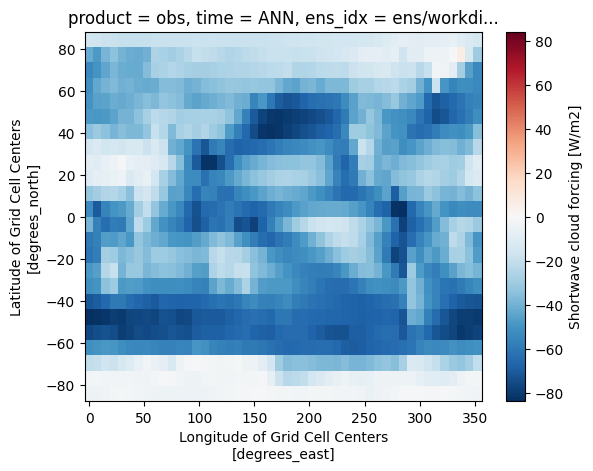

In [ ]:
# sst4k_dataset = sst4k_dataset.transpose("time","product","ens_idx","lat","lon")
sst4k_dataset["SWCF"].isel(time=0, product=1, ens_idx=0).plot()

NameError: name 'sst4k_dataset' is not defined

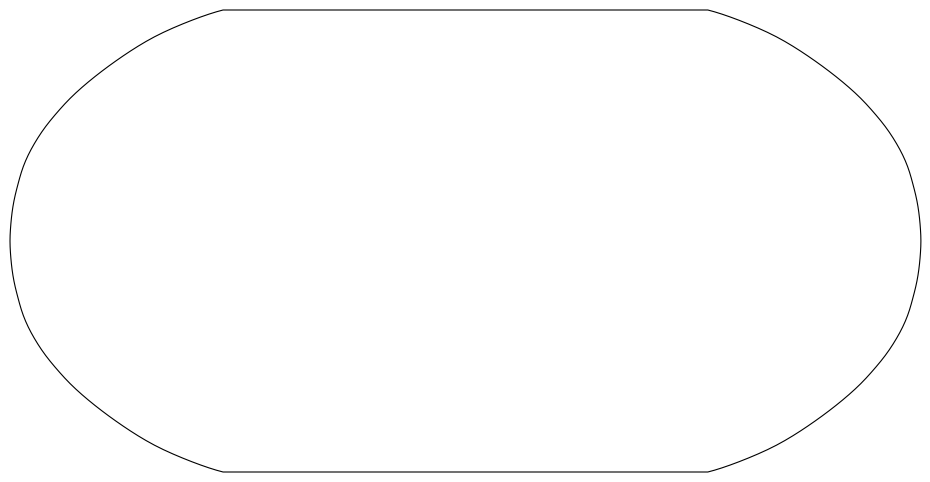

In [1]:
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())

sst4k_dataset["SWCF"].isel(time=0, product=0, ens_idx=0).plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    cbar_kwargs={'label': 'SWCF (W/m²)'}
)

ax.coastlines()
